# Decode trajectory viewer

Load one JSONL record from `python -m doublebackprop.dump_decode_trajectories` (field `trajectory`: list of token-id vectors per step). See [`visualization/README.md`](../README.md).

The first code cell adds the repository root to `sys.path` so `doublebackprop` imports without an editable install; alternatively use `pip install -e doublebackprop` and a kernel that uses that environment.

After changing `doublebackprop/viz_puzzle_state.py`, restart the kernel or re-run the first code cell, then the plotting cell (the plotting cell re-imports helpers from that module).

Default path below points at `visualization/outputs/` after running `scripts/sudoku_trajectory_dump.sh`.

**Paired runs:** after `pair_trajectory_dumps`, use the later section for side-by-side MLM vs BPTT on the same `example_index`.

In [1]:
import sys
from pathlib import Path

# Make `import doublebackprop` work without a manual pip install: add repo root to sys.path.
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "doublebackprop" / "viz_puzzle_state.py").is_file():
            return p
    raise RuntimeError(
        "Could not find repo root (looked for doublebackprop/viz_puzzle_state.py). "
        "Open the notebook from the repo or `cd` to the repository root, "
        "or run: pip install -e doublebackprop"
    )


_root = _repo_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as w

from doublebackprop.viz_puzzle_state import (
    sudoku_ids_to_digit_grid,
    sudoku_ids_to_grid,
    n_queens_ids_to_grid,
    infer_dataset,
    trajectory_to_grids,
)

JSONL = Path("../outputs/trajectories_sudoku_mlm.jsonl")
LINE_INDEX = 0

lines = JSONL.read_text().strip().splitlines()
rec = json.loads(lines[LINE_INDEX])
traj = rec["trajectory"]
tags = rec.get("tags") or {}
ds = infer_dataset(tags)
print("dataset:", ds, "steps:", len(traj))

dataset: sudoku_extreme steps: 14


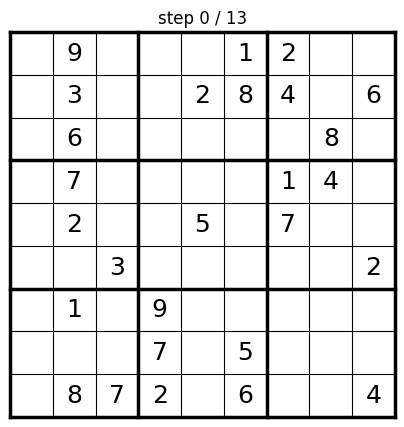

In [2]:
from IPython.display import clear_output, display
import importlib

import doublebackprop.viz_puzzle_state as _vps

importlib.reload(_vps)
from doublebackprop.viz_puzzle_state import (
    n_queens_ids_to_grid,
    sudoku_ids_to_digit_grid,
    sudoku_ids_to_grid,
)

_ds = ds.lower()
_IS_SUDOKU = "sudoku" in _ds


def ids_to_grid(step_ids):
    if _IS_SUDOKU:
        return sudoku_ids_to_grid(step_ids)
    if "queens" in _ds or "n_queens" in _ds:
        return n_queens_ids_to_grid(step_ids)
    return np.array(step_ids, dtype=np.float32)


def _draw_sudoku_board(step_idx: int) -> None:
    """Digits 1–9 from SimpleSpaceTokenizer.for_numbers(10); empty = [MASK] or '0'."""
    digit_grid = sudoku_ids_to_digit_grid(traj[step_idx])
    ax.clear()
    ax.set_xlim(0, 9)
    ax.set_ylim(9, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"step {step_idx} / {len(traj) - 1}")
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.8
        ax.axhline(i, color="black", linewidth=lw, clip_on=False)
        ax.axvline(i, color="black", linewidth=lw, clip_on=False)
    for r in range(9):
        for c in range(9):
            ch = digit_grid[r, c]
            if ch:
                ax.text(
                    c + 0.5,
                    r + 0.5,
                    str(ch),
                    ha="center",
                    va="center",
                    fontsize=18,
                )


# Inline matplotlib shows a static PNG once; re-display the figure inside an Output widget.
fig, ax = plt.subplots(figsize=(5, 5))
if _IS_SUDOKU:
    _draw_sudoku_board(0)
else:
    im = ax.imshow(ids_to_grid(traj[0]), vmin=-1, vmax=10, cmap="viridis")
    ax.set_title(f"step 0 / {len(traj)-1}")
    plt.colorbar(im, ax=ax)

plot_out = w.Output()


def _redraw(step: int) -> None:
    step = int(step)
    if _IS_SUDOKU:
        _draw_sudoku_board(step)
    else:
        g = ids_to_grid(traj[step])
        im.set_data(g)
        ax.set_title(f"step {step} / {len(traj)-1}")
    with plot_out:
        clear_output(wait=True)
        display(fig)


slider = w.IntSlider(
    value=0, min=0, max=len(traj) - 1, step=1, description="step"
)


def _on_slider(change):
    _redraw(change["new"])


slider.observe(_on_slider, names="value")

with plot_out:
    display(fig)

display(w.VBox([slider, plot_out]))

## Paired MLM vs BPTT (same `example_index`)

After `python -m doublebackprop.pair_trajectory_dumps --mlm ... --bptt ... --out paired.jsonl`, set `PAIRED_JSONL` in the **setup** cell.

Use **three code cells** in order:

1. **Setup** — load the paired row and define helpers.
2. **Static fill-step figures** (Sudoku) — heatmaps + optional Δ; plain `plt.show()` (not in the widget). Digits overlaid on MLM/BPTT panels are **final predictions**; on Δ, **ground-truth** digits from `truth_text` when parseable (else BPTT final).
3. **Interactive** — step slider updates **only** the two digit boards (no heatmaps).

Re-run **Setup** after changing `PAIR_ROW` or the JSONL path, then re-run static + interactive.

If decode depths differ, the slider goes to `max(steps)`; each side clamps past its last frame.


In [3]:
# Paired — setup (run the repo-path cell first)
import importlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as w

import doublebackprop.viz_puzzle_state as _vps

importlib.reload(_vps)
from doublebackprop.viz_puzzle_state import (
    infer_dataset,
    n_queens_ids_to_grid,
    overlay_sudoku_digits_on_heatmap_ax,
    sudoku_ids_to_digit_grid,
    sudoku_ids_to_grid,
    sudoku_first_nonmask_step_grid,
    sudoku_truth_text_to_digit_grid,
)

PAIRED_JSONL = _root / "visualization/outputs/paired_sudoku_mlm_vs_bptt.jsonl"
PAIR_ROW = 5
SHOW_DELTA = True  # static fill-step cell only

if not PAIRED_JSONL.is_file():
    raise FileNotFoundError(
        f"Missing {PAIRED_JSONL}. Generate with:\n"
        "  python -m doublebackprop.pair_trajectory_dumps "
        "--mlm mlm.jsonl --bptt bptt.jsonl --out paired.jsonl"
    )

paired_rows = [json.loads(l) for l in PAIRED_JSONL.read_text().strip().splitlines()]
row = paired_rows[PAIR_ROW]
traj_mlm = row["mlm"]["trajectory"]
traj_bptt = row["bptt"]["trajectory"]
tags = row["mlm"].get("tags") or row["bptt"].get("tags") or {}
_ds = infer_dataset(tags).lower()
_IS_SUDOKU = "sudoku" in _ds
_IS_NQ = "queens" in _ds or "n_queens" in _ds


def _ids_to_grid(step_ids):
    if _IS_SUDOKU:
        return sudoku_ids_to_grid(step_ids)
    if _IS_NQ:
        return n_queens_ids_to_grid(step_ids)
    return np.asarray(step_ids, dtype=np.float32)


def _draw_sudoku(ax, step_ids, title: str):
    digit_grid = sudoku_ids_to_digit_grid(step_ids)
    ax.clear()
    ax.set_xlim(0, 9)
    ax.set_ylim(9, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11)
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.8
        ax.axhline(i, color="black", linewidth=lw, clip_on=False)
        ax.axvline(i, color="black", linewidth=lw, clip_on=False)
    for r in range(9):
        for c in range(9):
            ch = digit_grid[r, c]
            if ch:
                ax.text(
                    c + 0.5,
                    r + 0.5,
                    str(ch),
                    ha="center",
                    va="center",
                    fontsize=16,
                )


em_m = row.get("mlm_exact_match", row["mlm"].get("exact_match"))
em_b = row.get("bptt_exact_match", row["bptt"].get("exact_match"))
ex_idx = row.get("example_index", "?")

print(
    f"example_index={ex_idx} | MLM exact_match={em_m} | BPTT exact_match={em_b} | "
    f"steps MLM={len(traj_mlm)} BPTT={len(traj_bptt)} | dataset={_ds!r}"
)

_slider_max = max(len(traj_mlm), len(traj_bptt)) - 1


example_index=10 | MLM exact_match=False | BPTT exact_match=True | steps MLM=25 BPTT=7 | dataset='sudoku_extreme'


### Static fill-step figures (Sudoku)

Run after **Setup**. Independent of the step slider. Digits use white text with a dark outline (paper-style).


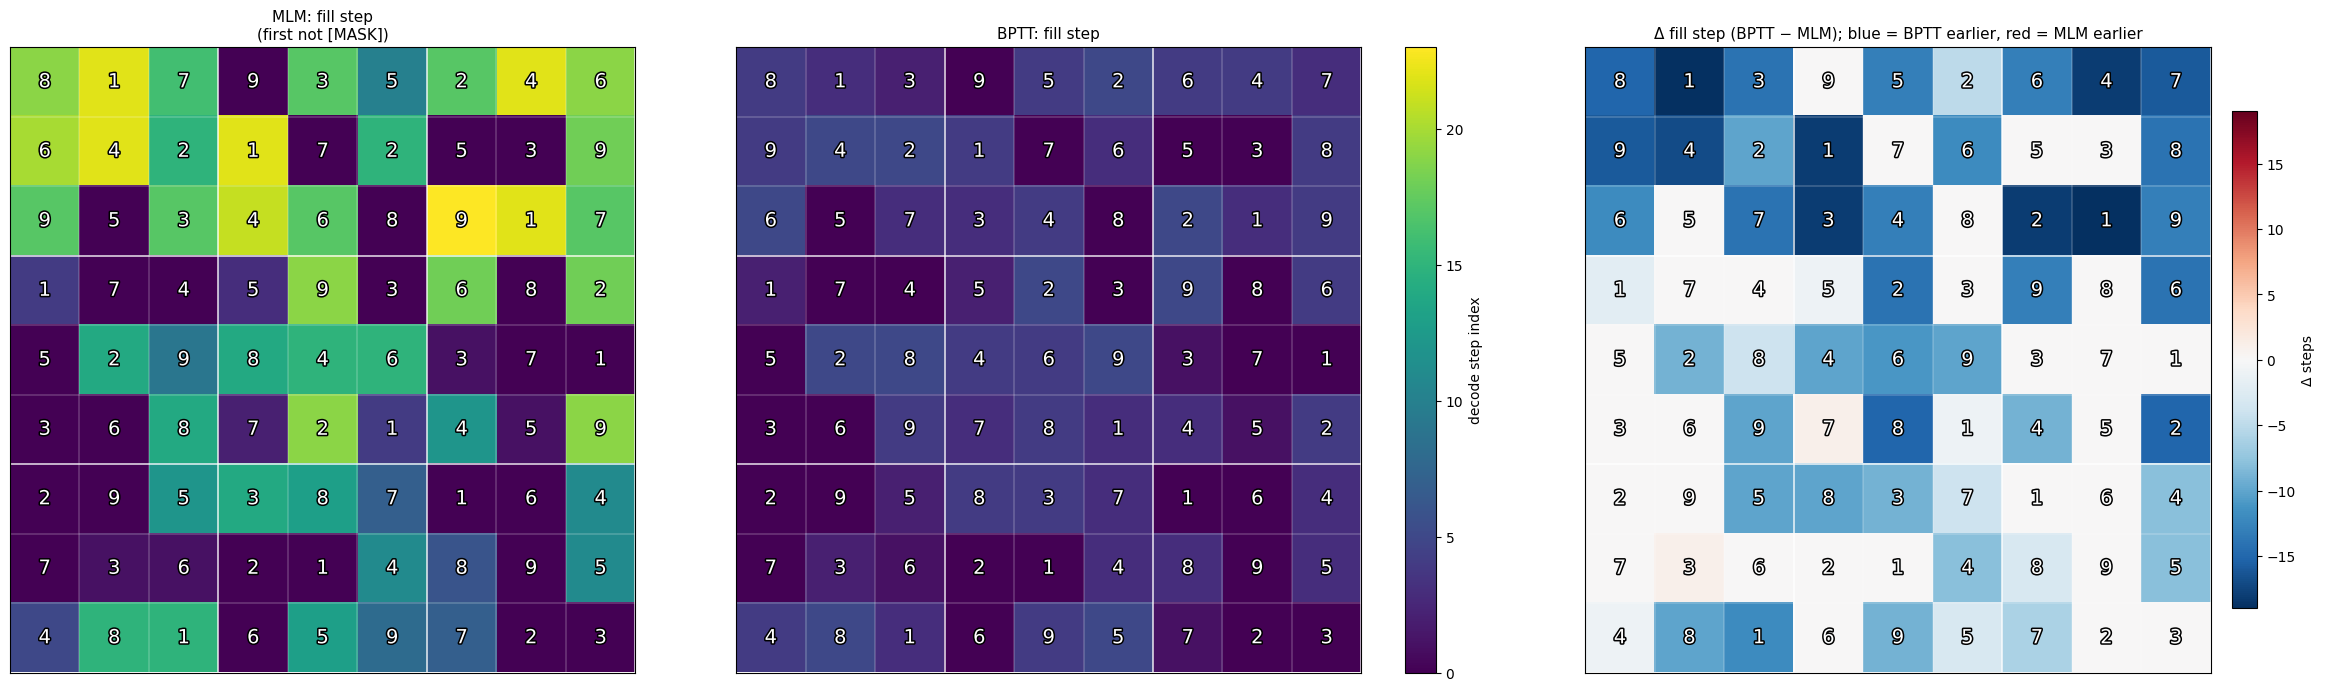

In [4]:
# Paired — static fill-step heatmaps (Sudoku only; run after Setup)
# When SHOW_DELTA: MLM | BPTT | Δ in one row (equal width). Digit overlay uses imshow centers (col, row).
if not _IS_SUDOKU:
    print("Skipping: fill-step heatmaps are for Sudoku paired rows.")
else:
    fill_m = sudoku_first_nonmask_step_grid(traj_mlm)
    fill_b = sudoku_first_nonmask_step_grid(traj_bptt)
    digits_m = sudoku_ids_to_digit_grid(traj_mlm[-1])
    digits_b = sudoku_ids_to_digit_grid(traj_bptt[-1])
    _tt = row["mlm"].get("truth_text") or row["bptt"].get("truth_text") or ""
    digits_truth = sudoku_truth_text_to_digit_grid(_tt)

    stack = np.concatenate([fill_m.ravel(), fill_b.ravel()])
    vmax = float(np.nanmax(stack))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    cmap = mpl.cm.viridis.copy()
    cmap.set_bad(color="#d8d8d8")
    m_m = np.ma.masked_invalid(fill_m)
    m_b = np.ma.masked_invalid(fill_b)

    def _style_board(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        for i in range(10):
            lw = 1.4 if i % 3 == 0 else 0.35
            ax.axhline(i - 0.5, color="white", linewidth=lw, alpha=0.7)
            ax.axvline(i - 0.5, color="white", linewidth=lw, alpha=0.7)
        ax.set_aspect("equal")

    _fs = 14

    if SHOW_DELTA:
        fig_s, (ax_fl, ax_fr, ax_d) = plt.subplots(
            1, 3, figsize=(24, 6.8), layout="constrained", sharey=True
        )
        ax_fl.imshow(
            m_m, vmin=0, vmax=vmax, cmap=cmap, interpolation="nearest", origin="upper"
        )
        ax_fr.imshow(
            m_b, vmin=0, vmax=vmax, cmap=cmap, interpolation="nearest", origin="upper"
        )
        ax_fl.set_title("MLM: fill step\n(first not [MASK])", fontsize=11)
        ax_fr.set_title("BPTT: fill step", fontsize=11)
        for ax in (ax_fl, ax_fr):
            _style_board(ax)
        overlay_sudoku_digits_on_heatmap_ax(ax_fl, digits_m, fontsize=_fs)
        overlay_sudoku_digits_on_heatmap_ax(ax_fr, digits_b, fontsize=_fs)
        fig_s.colorbar(
            ax_fl.images[0],
            ax=[ax_fl, ax_fr],
            fraction=0.035,
            pad=0.03,
            label="decode step index",
        )

        delta = fill_b - fill_m
        vmax_d = float(np.nanmax(np.abs(delta)))
        if np.isfinite(vmax_d) and vmax_d > 0:
            ax_d.imshow(
                np.ma.masked_invalid(delta),
                cmap="RdBu_r",
                vmin=-vmax_d,
                vmax=vmax_d,
                interpolation="nearest",
                origin="upper",
            )
            fig_s.colorbar(
                ax_d.images[0], ax=ax_d, fraction=0.035, pad=0.03, label="Δ steps"
            )
        ax_d.set_title(
            "Δ fill step (BPTT − MLM); blue = BPTT earlier, red = MLM earlier",
            fontsize=11,
        )
        _style_board(ax_d)
        dgrid = digits_truth if digits_truth is not None else digits_b
        overlay_sudoku_digits_on_heatmap_ax(ax_d, dgrid, fontsize=_fs)
    else:
        fig_s, (ax_fl, ax_fr) = plt.subplots(
            1, 2, figsize=(16, 6.5), layout="constrained", sharey=True
        )
        ax_fl.imshow(
            m_m, vmin=0, vmax=vmax, cmap=cmap, interpolation="nearest", origin="upper"
        )
        ax_fr.imshow(
            m_b, vmin=0, vmax=vmax, cmap=cmap, interpolation="nearest", origin="upper"
        )
        ax_fl.set_title("MLM: fill step\n(first not [MASK])", fontsize=11)
        ax_fr.set_title("BPTT: fill step", fontsize=11)
        for ax in (ax_fl, ax_fr):
            _style_board(ax)
        overlay_sudoku_digits_on_heatmap_ax(ax_fl, digits_m, fontsize=_fs)
        overlay_sudoku_digits_on_heatmap_ax(ax_fr, digits_b, fontsize=_fs)
        fig_s.colorbar(
            ax_fl.images[0],
            ax=[ax_fl, ax_fr],
            fraction=0.035,
            pad=0.03,
            label="decode step index",
        )

    plt.show()


### Interactive paired boards

Slider updates **only** the two boards above the text summary.


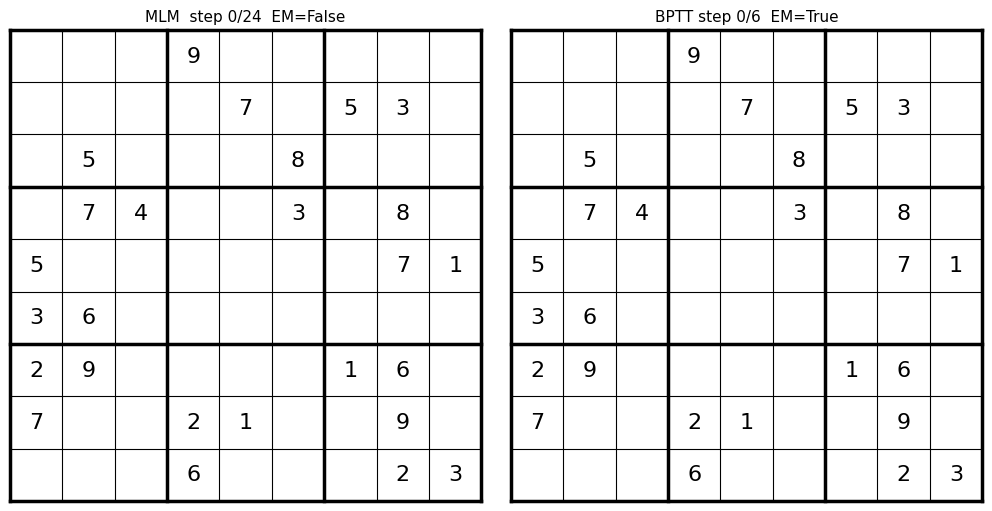

In [55]:
# Paired — interactive boards only (slider does not redraw heatmaps)
from IPython.display import clear_output, display

fig_p, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
_im_l = _im_r = None

if not _IS_SUDOKU:
    g0 = _ids_to_grid(traj_mlm[0])
    g1 = _ids_to_grid(traj_bptt[0])
    _im_l = ax_l.imshow(g0, vmin=-1, vmax=16, cmap="viridis")
    _im_r = ax_r.imshow(g1, vmin=-1, vmax=16, cmap="viridis")
    plt.colorbar(_im_r, ax=ax_r, fraction=0.046)

plot_p = w.Output()


def _redraw_paired(step: int) -> None:
    step = int(step)
    sm = min(step, len(traj_mlm) - 1)
    sb = min(step, len(traj_bptt) - 1)
    if _IS_SUDOKU:
        _draw_sudoku(
            ax_l,
            traj_mlm[sm],
            f"MLM  step {sm}/{len(traj_mlm) - 1}  EM={em_m}",
        )
        _draw_sudoku(
            ax_r,
            traj_bptt[sb],
            f"BPTT step {sb}/{len(traj_bptt) - 1}  EM={em_b}",
        )
    else:
        assert _im_l is not None and _im_r is not None
        _im_l.set_data(_ids_to_grid(traj_mlm[sm]))
        _im_r.set_data(_ids_to_grid(traj_bptt[sb]))
        ax_l.set_title(f"MLM  step {sm}/{len(traj_mlm) - 1}  EM={em_m}")
        ax_r.set_title(f"BPTT step {sb}/{len(traj_bptt) - 1}  EM={em_b}")
    with plot_p:
        clear_output(wait=True)
        display(fig_p)


slider_p = w.IntSlider(
    value=0, min=0, max=max(0, _slider_max), step=1, description="step"
)


def _on_paired(change):
    _redraw_paired(change["new"])


slider_p.observe(_on_paired, names="value")

_truth_m = row["mlm"].get("truth_text", "")
_truth_b = row["bptt"].get("truth_text", "")
_pred_m = row["mlm"].get("pred_text", "")
_pred_b = row["bptt"].get("pred_text", "")

summary = w.HTML(
    "<pre style='font-size:11px;white-space:pre-wrap'>"
    f"<b>MLM</b> pred (final): {_pred_m[:200]}{'…' if len(_pred_m) > 200 else ''}\n"
    f"<b>MLM</b> truth:        {_truth_m[:200]}{'…' if len(_truth_m) > 200 else ''}\n\n"
    f"<b>BPTT</b> pred (final): {_pred_b[:200]}{'…' if len(_pred_b) > 200 else ''}\n"
    f"<b>BPTT</b> truth:        {_truth_b[:200]}{'…' if len(_truth_b) > 200 else ''}"
    "</pre>"
)

_redraw_paired(0)
display(w.VBox([slider_p, plot_p, summary]))


### Reading paired boards

1. **Exact match flags** — Titles show `EM=True/False` per checkpoint. Same `truth_text` on both sides; different `pred_text` means the models diverged.
2. **Slider** — Scrub time; see when each side commits digits.
3. **Fill-step heatmaps (Sudoku)** — In the **static** cell: first step each cell left `[MASK]`. Optional Δ = BPTT − MLM. The **interactive** cell is boards vs. step only.
4. **Different trajectory lengths** — Slider max = longer run; shorter side clamps at its last frame.
5. **Sudoku** — At the last step, compare to truth; scrub to see when errors appear.
6. **N-queens** — `imshow` of token ids; see `viz_puzzle_state.n_queens_ids_to_grid`.
